# Global Earthquakes

Reads from `quakes.sqlite`, populated by `fetch_quakes.py` (USGS FDSN catalog).

**Two coverage regimes** are mixed in this database on purpose:
- **M≥4.0 from 1965**, the WWSSN era. M4 detection is roughly comparable across this span.
- **M≥7.0 from 1900**, the long pre-WWSSN tail. Large quakes radiate enough energy that they were detected globally even by the sparse early-1900s networks, so M7+ counts are reliable back ~125 years.

Each plot is also saved to `figures/` as PNG. Re-execute the notebook to refresh them.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB = Path('quakes.sqlite')
FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

M4_COMPLETE_FROM = 1965
NETWORK_UPGRADE_YEAR = 2000
M7_COMPLETE_FROM = 1900
GREAT_QUAKE_MAG = 8.5

def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, dpi=140, bbox_inches='tight', facecolor='white')

with sqlite3.connect(DB) as conn:
    df = pd.read_sql_query(
        'SELECT id, time_ms, mag, mag_type, lat, lon, depth_km, place '
        'FROM quakes ORDER BY time_ms',
        conn,
    )
df['time'] = pd.to_datetime(df['time_ms'], unit='ms', utc=True)
df['year'] = df['time'].dt.year

latest = df['time'].max()
current_year = int(latest.year)
year_start = pd.Timestamp(f'{current_year}-01-01', tz='UTC')
year_end = pd.Timestamp(f'{current_year + 1}-01-01', tz='UTC')
year_fraction = (latest - year_start) / (year_end - year_start)
print(f'Loaded {len(df):,} events, {df["time"].min():%Y-%m-%d} → {latest:%Y-%m-%d}')
print(f'Current year ({current_year}) is {year_fraction:.1%} complete — handled separately in plots.')
df.head()

Loaded 530,895 events, 1900-01-05 → 2026-05-13
Current year (2026) is 36.4% complete — handled separately in plots.


,id,time_ms,mag,mag_type,lat,lon,depth_km,place,time,year
0,cent19000105190000000,-2208574800000,7.0,ms,-3.0,102.0,NaN,"Southern Sumatra, Indonesia",1900-01-05 19:00:00+00:00,1900
1,cent19000111090700000,-2208091980000,7.0,ms,-5.0,148.0,NaN,Bismarck Sea,1900-01-11 09:07:00+00:00,1900
2,cent19000120063300000,-2207323620000,7.3,mw,20.0,-105.0,NaN,"Jalisco, Mexico",1900-01-20 06:33:00+00:00,1900
3,cent19000131192200000,-2206327080000,7.5,mj,48.0,146.0,450.0,Sea of Okhotsk,1900-01-31 19:22:00+00:00,1900
4,cent19000511172300000,-2197694220000,7.0,mj,38.7,141.1,5.0,"Northern Honshu, Japan",1900-05-11 17:23:00+00:00,1900


## Magnitude vs Time

Each dot is one earthquake. M≥7.0 events highlighted as gold triangles. The grey shaded band on the right edge marks the partial current year. Note the pre-1965 region: only gold triangles appear because that's the M7-only historical window — the M4 catalog doesn't extend that far back.

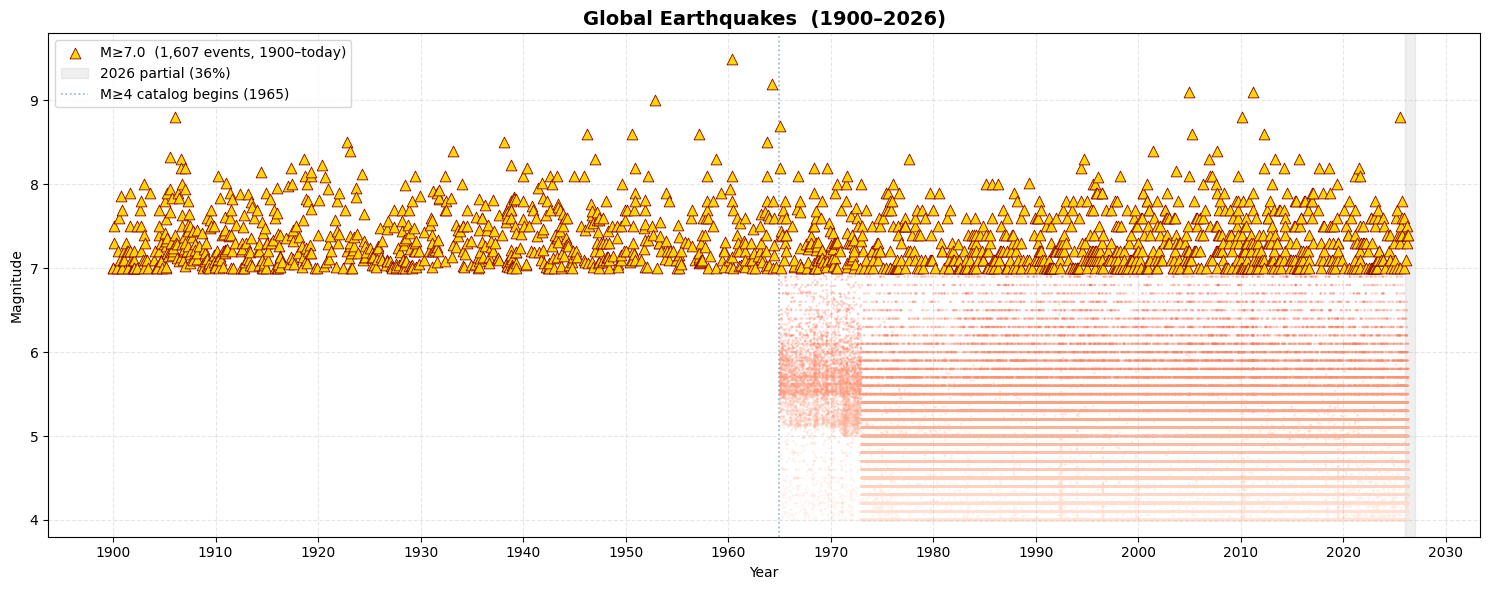

In [2]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.scatter(df['time'], df['mag'], c=df['mag'], cmap='Reds',
           alpha=0.25, s=3, linewidth=0)

major = df[df['mag'] >= 7.0]
ax.scatter(major['time'], major['mag'], c='gold', s=60, marker='^',
           edgecolors='darkred', linewidth=0.6, zorder=5,
           label=f'M≥7.0  ({len(major):,} events, 1900–today)')

ax.axvspan(year_start, year_end, color='grey', alpha=0.12, zorder=0,
           label=f'{current_year} partial ({year_fraction:.0%})')
ax.axvline(pd.Timestamp(f'{M4_COMPLETE_FROM}-01-01', tz='UTC'),
           color='steelblue', linestyle=':', linewidth=1.2, alpha=0.6,
           label=f'M≥4 catalog begins ({M4_COMPLETE_FROM})')

ax.set_xlabel('Year')
ax.set_ylabel('Magnitude')
ax.set_title(f'Global Earthquakes  ({df["year"].min()}–{current_year})',
             fontsize=14, fontweight='bold')
ax.xaxis.set_major_locator(mdates.YearLocator(10))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_ylim(3.8, df['mag'].max() + 0.3)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left')
plt.tight_layout()
save_fig(fig, '01_magnitude_vs_time.png')
plt.show()

## Yearly Counts by Magnitude Band (M4 catalog only)

Showing complete years from 1965 onwards — the M≥4 catalog era. Trend line is a linear fit on the **post-network-upgrade era (≥2000)** only — once digital regional networks were fully online and M4 detection had largely stabilized.

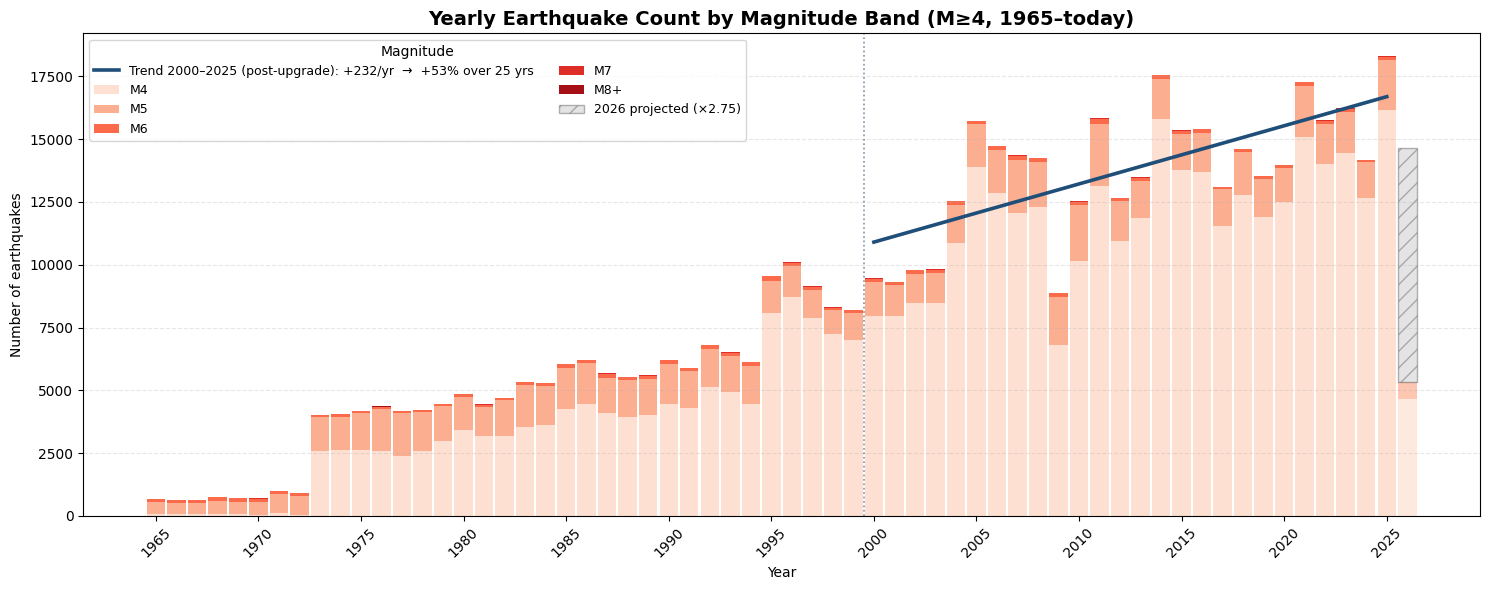

In [3]:
bands = [(4, 5, 'M4'), (5, 6, 'M5'), (6, 7, 'M6'), (7, 8, 'M7'), (8, 11, 'M8+')]
band_colors = ['#fee0d2', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']

m4_era = df[df['year'] >= M4_COMPLETE_FROM]
by_year = pd.DataFrame({'year': sorted(m4_era['year'].unique())}).set_index('year')
for lo, hi, label in bands:
    sel = m4_era[(m4_era['mag'] >= lo) & (m4_era['mag'] < hi)]
    by_year[label] = sel.groupby('year').size()
by_year = by_year.fillna(0).astype(int)

complete_years = by_year.loc[by_year.index < current_year]
partial_row = by_year.loc[[current_year]] if current_year in by_year.index else None

fig, ax = plt.subplots(figsize=(15, 6))
year_to_x = {y: i for i, y in enumerate(by_year.index)}

bottom = np.zeros(len(complete_years))
for (lo, hi, label), color in zip(bands, band_colors):
    vals = complete_years[label].to_numpy()
    ax.bar([year_to_x[y] for y in complete_years.index], vals, bottom=bottom,
           color=color, width=0.9, label=label)
    bottom += vals

if partial_row is not None and year_fraction > 0:
    px = year_to_x[current_year]
    actual_total = int(partial_row.sum(axis=1).iloc[0])
    projected_total = actual_total / year_fraction
    bottom_p = 0.0
    for (lo, hi, label), color in zip(bands, band_colors):
        v = int(partial_row[label].iloc[0])
        ax.bar(px, v, bottom=bottom_p, color=color, width=0.9, alpha=0.7)
        bottom_p += v
    ax.bar(px, projected_total - actual_total, bottom=actual_total, color='lightgrey',
           width=0.9, alpha=0.6, hatch='//', edgecolor='grey',
           label=f'{current_year} projected (×{1/year_fraction:.2f})')

modern = complete_years.loc[complete_years.index >= NETWORK_UPGRADE_YEAR]
if len(modern) >= 5:
    m_yrs = modern.index.to_numpy()
    m_totals = modern.sum(axis=1).to_numpy()
    slope_m, intercept_m = np.polyfit(m_yrs, m_totals, 1)
    trend_m = slope_m * m_yrs + intercept_m
    n_yrs_m = m_yrs[-1] - m_yrs[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot([year_to_x[y] for y in m_yrs], trend_m, color='#1f4e79',
            linewidth=2.6,
            label=(f'Trend {m_yrs[0]}–{m_yrs[-1]} (post-upgrade): '
                   f'{slope_m:+.0f}/yr  →  {pct_m:+.0f}% over {n_yrs_m} yrs'))

if NETWORK_UPGRADE_YEAR in year_to_x:
    ax.axvline(year_to_x[NETWORK_UPGRADE_YEAR] - 0.5, color='#1f4e79',
               linestyle=':', linewidth=1.2, alpha=0.6)

ax.set_xlabel('Year')
ax.set_ylabel('Number of earthquakes')
ax.set_title('Yearly Earthquake Count by Magnitude Band (M≥4, 1965–today)',
             fontsize=14, fontweight='bold')
ax.legend(title='Magnitude', loc='upper left', ncol=2, fontsize=9)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
xpos = np.arange(len(by_year))
ax.set_xticks(xpos[::5])
ax.set_xticklabels(by_year.index[::5], rotation=45)
plt.tight_layout()
save_fig(fig, '02_yearly_by_band.png')
plt.show()

## M≥7.0 Yearly Counts — the detection-bias control (1900 → today)

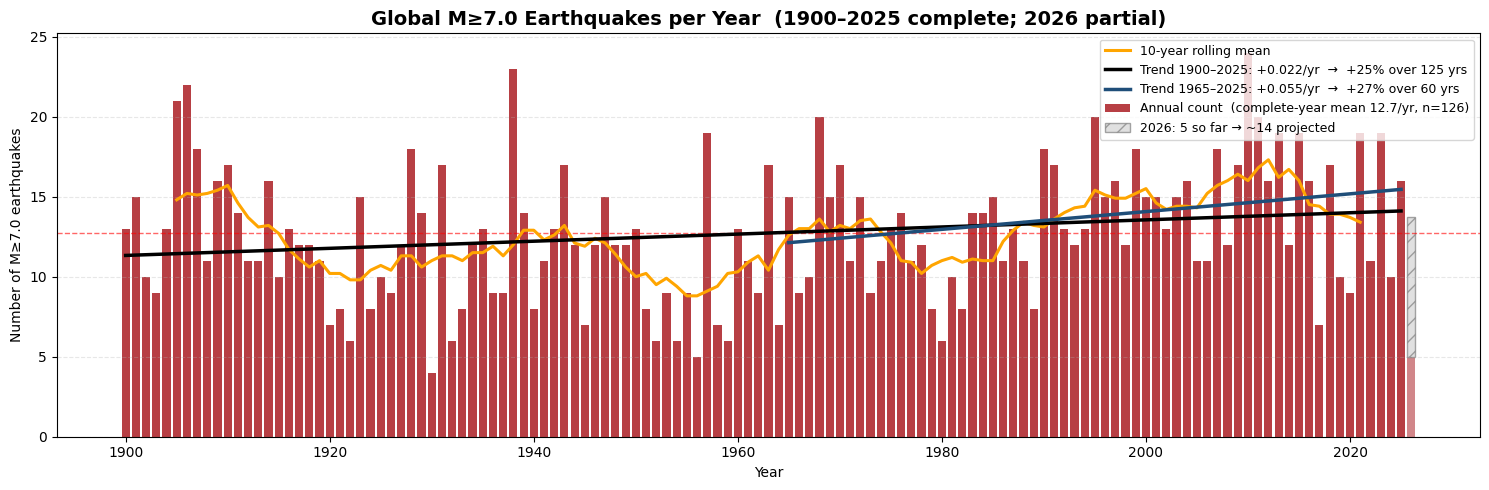

In [4]:
big = df[df['mag'] >= 7.0]
yearly_all = big.groupby('year').size()
yearly_all = yearly_all.reindex(
    range(yearly_all.index.min(), yearly_all.index.max() + 1), fill_value=0
)
yearly = yearly_all[yearly_all.index < current_year]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(yearly.index, yearly.values, color='#a50f15', alpha=0.8,
       label=f'Annual count  (complete-year mean {yearly.mean():.1f}/yr, n={len(yearly)})')

if current_year in yearly_all.index and year_fraction > 0:
    actual7 = int(yearly_all.loc[current_year])
    projected7 = actual7 / year_fraction
    ax.bar(current_year, actual7, color='#a50f15', alpha=0.5)
    ax.bar(current_year, projected7 - actual7, bottom=actual7,
           color='lightgrey', alpha=0.7, hatch='//', edgecolor='grey',
           label=f'{current_year}: {actual7} so far → ~{projected7:.0f} projected')

ax.axhline(yearly.mean(), color='red', linestyle='--', linewidth=1, alpha=0.6)
ax.plot(yearly.index, yearly.rolling(10, center=True).mean(),
        color='orange', linewidth=2.2, label='10-year rolling mean')

yi_long = yearly.index.to_numpy()
yv_long = yearly.values
slope_long, intercept_long = np.polyfit(yi_long, yv_long, 1)
trend_long = slope_long * yi_long + intercept_long
n_long = yi_long[-1] - yi_long[0]
pct_long = (trend_long[-1] - trend_long[0]) / trend_long[0] * 100
ax.plot(yi_long, trend_long, color='black', linewidth=2.5,
        label=f'Trend {yi_long[0]}–{yi_long[-1]}: {slope_long:+.3f}/yr  →  {pct_long:+.0f}% over {n_long} yrs')

yearly_modern = yearly[yearly.index >= M4_COMPLETE_FROM]
if len(yearly_modern) >= 5:
    yi_m = yearly_modern.index.to_numpy()
    yv_m = yearly_modern.values
    slope_m, intercept_m = np.polyfit(yi_m, yv_m, 1)
    trend_m = slope_m * yi_m + intercept_m
    n_m = yi_m[-1] - yi_m[0]
    pct_m = (trend_m[-1] - trend_m[0]) / trend_m[0] * 100
    ax.plot(yi_m, trend_m, color='#1f4e79', linewidth=2.5,
            label=f'Trend {yi_m[0]}–{yi_m[-1]}: {slope_m:+.3f}/yr  →  {pct_m:+.0f}% over {n_m} yrs')

ax.set_xlabel('Year')
ax.set_ylabel('Number of M≥7.0 earthquakes')
ax.set_title(f'Global M≥7.0 Earthquakes per Year  ({yi_long[0]}–{yi_long[-1]} complete; {current_year} partial)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
save_fig(fig, '03_m7_yearly.png')
plt.show()

## M≥7.0 Trailing 12-Month Count

For every day in the catalog, the count of M≥7 events in the **preceding 365 days**. Sidesteps the calendar-bin noise and partial-year problems of the yearly view. The red dashed line is the long-run yearly mean; the shaded band is ±1σ of the yearly counts.

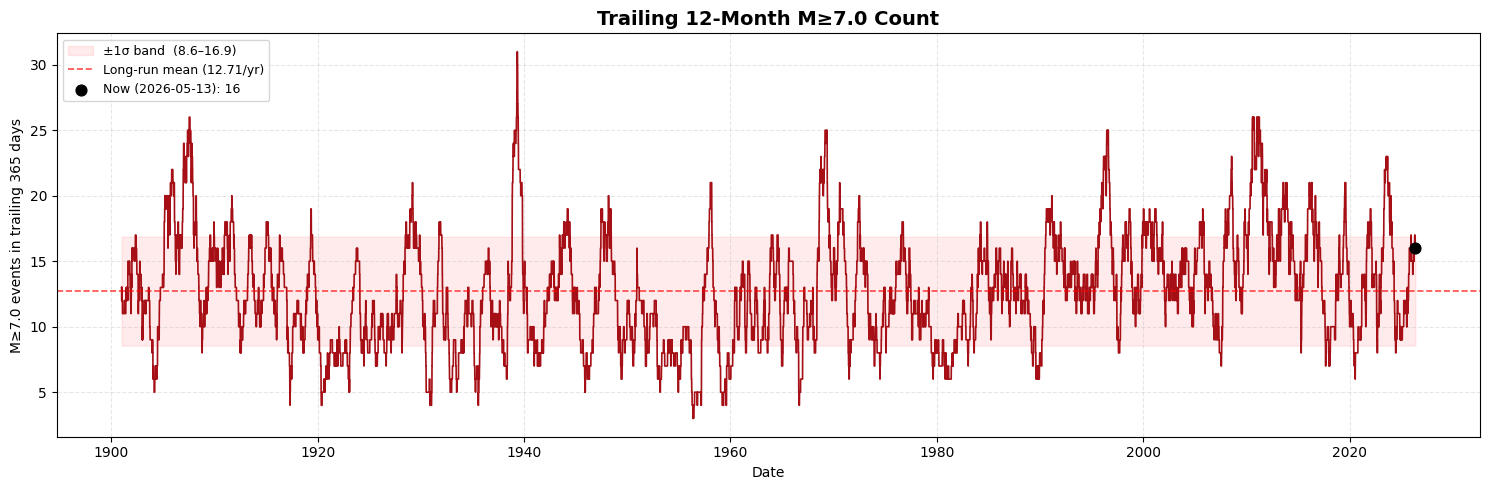

Trailing-12-month M≥7 count as of 2026-05-13: 16
  Long-run yearly mean:    12.71  (yearly stdev 4.16)
  Now vs. mean:            +3.3 events  (+26%, z=+0.79)
  Historical percentile:   76th  (of all daily trailing-12mo windows since 1901)


In [5]:
m7 = df[df['mag'] >= 7.0].copy()
m7['date'] = m7['time'].dt.normalize()

start = pd.Timestamp(f'{M7_COMPLETE_FROM}-01-01', tz='UTC')
end = latest.normalize()
daily_idx = pd.date_range(start, end, freq='D', tz='UTC')
daily = pd.Series(0, index=daily_idx, dtype=int)
per_day = m7.groupby('date').size()
daily.loc[per_day.index.intersection(daily.index)] = per_day.loc[
    per_day.index.intersection(daily.index)
].values

trailing = daily.rolling('365D').sum()
trailing_valid = trailing[trailing.index >= start + pd.Timedelta(days=365)]

yearly_mean = yearly.mean()
yearly_std = yearly.std()
current_t12 = trailing_valid.iloc[-1]
max_t12 = trailing_valid.max()
max_t12_date = trailing_valid.idxmax()
min_t12 = trailing_valid.min()
min_t12_date = trailing_valid.idxmin()

fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(trailing_valid.index,
                yearly_mean - yearly_std, yearly_mean + yearly_std,
                color='red', alpha=0.08, label=f'±1σ band  ({yearly_mean - yearly_std:.1f}–{yearly_mean + yearly_std:.1f})')
ax.plot(trailing_valid.index, trailing_valid.values,
        color='#a50f15', linewidth=1.2)
ax.axhline(yearly_mean, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Long-run mean ({yearly_mean:.2f}/yr)')
ax.scatter([latest], [current_t12], color='black', s=60, zorder=5,
           label=f'Now ({latest:%Y-%m-%d}): {current_t12:.0f}')

ax.set_xlabel('Date')
ax.set_ylabel('M≥7.0 events in trailing 365 days')
ax.set_title('Trailing 12-Month M≥7.0 Count',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
save_fig(fig, '04_m7_trailing_12mo.png')
plt.show()

pct_rank = (trailing_valid < current_t12).mean() * 100
z = (current_t12 - yearly_mean) / yearly_std
print(f'Trailing-12-month M≥7 count as of {latest:%Y-%m-%d}: {current_t12:.0f}')
print(f'  Long-run yearly mean:    {yearly_mean:.2f}  (yearly stdev {yearly_std:.2f})')
print(f'  Now vs. mean:            {(current_t12 - yearly_mean):+.1f} events  ({(current_t12/yearly_mean - 1)*100:+.0f}%, z={z:+.2f})')
print(f'  Historical percentile:   {pct_rank:.0f}th  (of all daily trailing-12mo windows since {M7_COMPLETE_FROM + 1})')

## Decadal Intensity — "are the contractions getting stronger?"

**Left panel — peak trailing-12mo count per decade.** **Right panel — cumulative seismic energy per decade**, expressed as the equivalent magnitude of a single quake releasing the decade's total seismic moment.

_Energy formula: M₀ = 10^(1.5 × Mw + 9.1) N·m (Hanks & Kanamori 1979)._

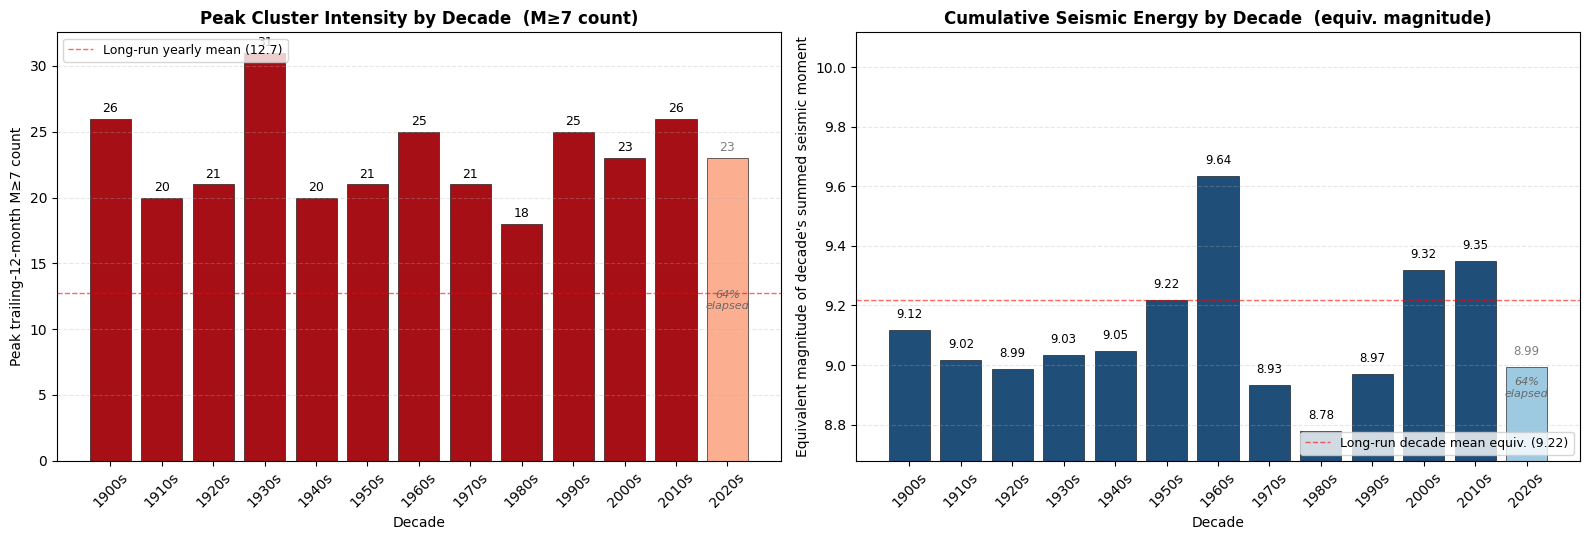

In [6]:
m7['decade'] = (m7['time'].dt.year // 10) * 10
trailing_decade = pd.Series(
    (trailing_valid.index.year // 10) * 10, index=trailing_valid.index
)
decade_peak = trailing_valid.groupby(trailing_decade).max()

m7['moment'] = 10 ** (1.5 * m7['mag'] + 9.1)
decade_moment = m7.groupby('decade')['moment'].sum()
decade_equiv_mag = (np.log10(decade_moment) - 9.1) / 1.5

current_decade = (current_year // 10) * 10
decade_elapsed_years = (latest - pd.Timestamp(f'{current_decade}-01-01', tz='UTC')).days / 365.25
decade_fraction = decade_elapsed_years / 10

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

decades = decade_peak.index.to_numpy()
is_partial = decades == current_decade
bar_colors = ['#a50f15' if not p else '#fcae91' for p in is_partial]
ax1.bar(decades, decade_peak.values, width=8, color=bar_colors,
        edgecolor='black', linewidth=0.4)
for d, v, p in zip(decades, decade_peak.values, is_partial):
    ax1.text(d, v + 0.5, f'{int(v)}', ha='center', fontsize=9,
             color='grey' if p else 'black')
ax1.axhline(yearly_mean, color='red', linestyle='--', linewidth=1, alpha=0.6,
            label=f'Long-run yearly mean ({yearly_mean:.1f})')
ax1.set_xlabel('Decade')
ax1.set_ylabel('Peak trailing-12-month M≥7 count')
ax1.set_title('Peak Cluster Intensity by Decade  (M≥7 count)',
              fontsize=12, fontweight='bold')
ax1.set_xticks(decades)
ax1.set_xticklabels([f"{d}s" for d in decades], rotation=45)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
if current_decade in decades:
    ax1.text(current_decade, decade_peak.loc[current_decade] / 2,
             f'{decade_fraction:.0%}\nelapsed', ha='center', fontsize=8,
             color='dimgrey', style='italic')
ax1.legend(loc='upper left', fontsize=9)

edecades = decade_equiv_mag.index.to_numpy()
eis_partial = edecades == current_decade
ebar_colors = ['#1f4e79' if not p else '#9ecae1' for p in eis_partial]
ax2.bar(edecades, decade_equiv_mag.values, width=8, color=ebar_colors,
        edgecolor='black', linewidth=0.4)
for d, v, p in zip(edecades, decade_equiv_mag.values, eis_partial):
    ax2.text(d, v + 0.04, f'{v:.2f}', ha='center', fontsize=8.5,
             color='grey' if p else 'black')
long_run_equiv = (np.log10(m7[m7['time'].dt.year < current_decade]['moment'].sum() /
                           ((current_decade - M7_COMPLETE_FROM) / 10)) - 9.1) / 1.5
ax2.axhline(long_run_equiv, color='red', linestyle='--', linewidth=1, alpha=0.6,
            label=f'Long-run decade mean equiv. ({long_run_equiv:.2f})')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Equivalent magnitude of decade\'s summed seismic moment')
ax2.set_title('Cumulative Seismic Energy by Decade  (equiv. magnitude)',
              fontsize=12, fontweight='bold')
ax2.set_xticks(edecades)
ax2.set_xticklabels([f"{d}s" for d in edecades], rotation=45)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(bottom=max(8.5, decade_equiv_mag.min() - 0.1))
if current_decade in edecades:
    ax2.text(current_decade, decade_equiv_mag.loc[current_decade] - 0.1,
             f'{decade_fraction:.0%}\nelapsed', ha='center', fontsize=8,
             color='dimgrey', style='italic')
ax2.legend(loc='lower right', fontsize=9)

plt.tight_layout()
save_fig(fig, '05_decadal_intensity.png')
plt.show()

## Great Quake Timing — "are the contractions coming closer together?"

Restricting to **M≥8.5 events** (the truly great earthquakes). Three regimes are visually called out with shaded bands, identified post-hoc by inspecting the data:

- **The Great Quake Drought (1965–2004)**: a 39.9-year stretch with zero M≥8.5 events. Longest gap in the catalog. Probability under a constant-rate model: ~0.5% for any single gap; ~8% for at least one such gap across 16 gaps.
- **The 2004–2012 Cluster**: 6 M≥8.5 events in ~8 years (Sumatra M9.1, Sumatra M8.6, Chile M8.8, Tōhoku M9.1, Wharton M8.6, etc.). Probability under a constant-rate model: ~0.05% — statistically unusual.
- **Current Quiet (2012–today)**: only 1 event in 13+ years (2025 Kamchatka M8.8).

Important caveat: these regimes are post-hoc — picked *because* the eye sees them. Any random Poisson process produces visible-looking 'regimes' if you draw boundaries around the gaps and clusters. The drought is unusual but within Poisson plausibility; the cluster is more statistically interesting.

**Left**: cumulative count over time. A steepening curve = accelerating; a flat shelf = a drought. **Right**: time gap between consecutive great quakes.

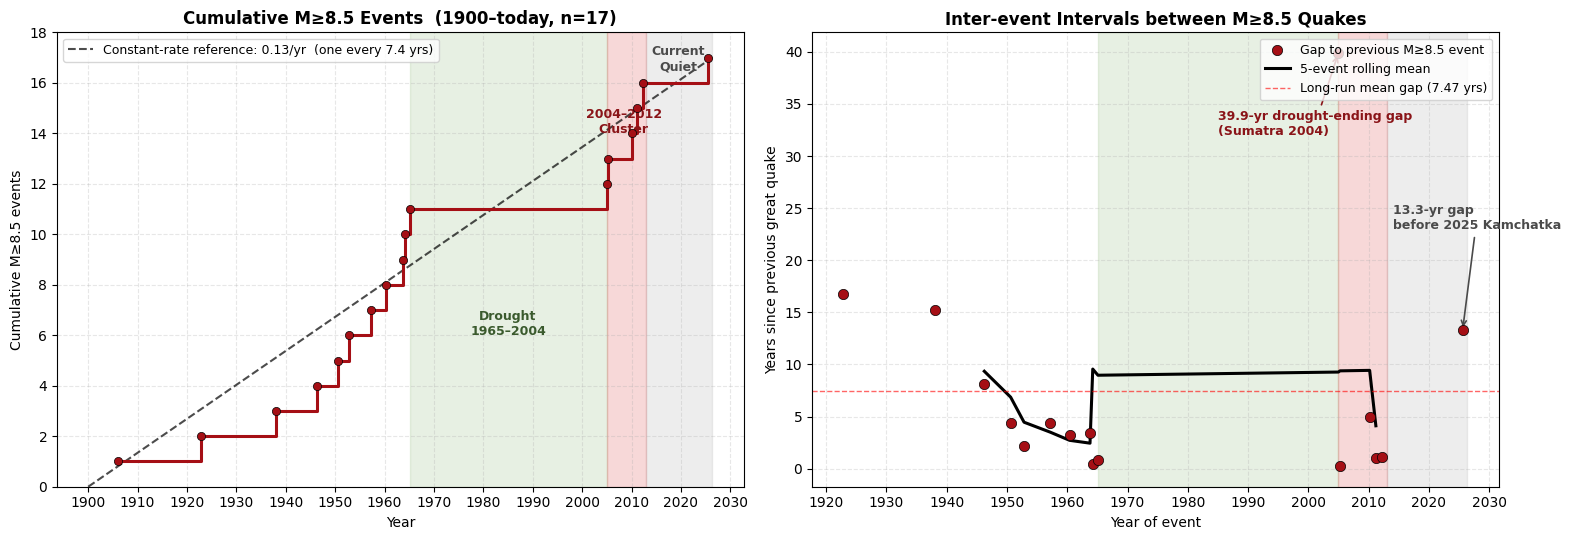

M≥8.5 events in catalog: 17
Long-run rate: 0.13/yr  (one every 7.4 years)

Three regimes (post-hoc identification):
  1965–2004 Drought:     0 events in 39.9 yrs  (expected ~5)
  2004–2012 Cluster:     6 events in  8.0 yrs  (expected ~1)
  2013–today  Quiet:     1 event  in 13.3 yrs  (expected ~2)

Rate per ~30-year window:
  1900–1929:  2 events  (0.07/yr, one every 15.0 yrs)
  1930–1959:  5 events  (0.17/yr, one every 6.0 yrs)
  1960–1989:  4 events  (0.13/yr, one every 7.5 yrs)
  1990–2019:  5 events  (0.17/yr, one every 6.0 yrs)
  2020–2025:  1 events  (0.14/yr, one every 7.0 yrs)


In [7]:
great = df[df['mag'] >= GREAT_QUAKE_MAG].sort_values('time').reset_index(drop=True)
great['interval_days'] = great['time'].diff().dt.total_seconds() / 86400
great['interval_years'] = great['interval_days'] / 365.25
n_great = len(great)

# Three identified regimes (post-hoc)
regimes = [
    (pd.Timestamp('1965-02-05', tz='UTC'), pd.Timestamp('2004-12-26', tz='UTC'),
     '#7fb069', 'Great Quake Drought\n(39.9 yrs, 0 events)'),
    (pd.Timestamp('2004-12-26', tz='UTC'), pd.Timestamp('2012-12-31', tz='UTC'),
     '#d62728', '2004–2012 Cluster\n(6 events in 8 yrs)'),
    (pd.Timestamp('2013-01-01', tz='UTC'), latest,
     '#a0a0a0', 'Current Quiet\n(1 event in 13 yrs)'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Panel 1: Cumulative count with regime shading
for start_r, end_r, color, label in regimes:
    ax1.axvspan(start_r, end_r, color=color, alpha=0.18)
ax1.step(great['time'], np.arange(1, n_great + 1), where='post',
         color='#a50f15', linewidth=2.2, zorder=3)
ax1.scatter(great['time'], np.arange(1, n_great + 1),
            color='#a50f15', s=35, zorder=4, edgecolor='black', linewidth=0.5)

ref_start = pd.Timestamp(f'{M7_COMPLETE_FROM}-01-01', tz='UTC')
ref_end = latest
ref_span_yrs = (ref_end - ref_start).days / 365.25
ref_rate = n_great / ref_span_yrs
ax1.plot([ref_start, ref_end], [0, n_great], color='black', linestyle='--',
         linewidth=1.5, alpha=0.7, zorder=2,
         label=f'Constant-rate reference: {ref_rate:.2f}/yr  (one every {1/ref_rate:.1f} yrs)')

# Annotate regimes inside the plot
ax1.text(pd.Timestamp('1985-01-01', tz='UTC'), 6, 'Drought\n1965–2004',
         ha='center', fontsize=9, color='#3a5a2d', fontweight='bold')
ax1.text(pd.Timestamp('2008-06-01', tz='UTC'), 14, '2004–2012\nCluster',
         ha='center', fontsize=9, color='#8a1418', fontweight='bold')
ax1.text(pd.Timestamp('2019-06-01', tz='UTC'), 16.5, 'Current\nQuiet',
         ha='center', fontsize=9, color='#4a4a4a', fontweight='bold')

ax1.set_xlabel('Year')
ax1.set_ylabel(f'Cumulative M≥{GREAT_QUAKE_MAG} events')
ax1.set_title(f'Cumulative M≥{GREAT_QUAKE_MAG} Events  ({M7_COMPLETE_FROM}–today, n={n_great})',
              fontsize=12, fontweight='bold')
ax1.xaxis.set_major_locator(mdates.YearLocator(10))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_ylim(0, n_great + 1)

# Panel 2: Inter-event intervals with regime shading
for start_r, end_r, color, label in regimes:
    ax2.axvspan(start_r, end_r, color=color, alpha=0.18)

intervals = great.dropna(subset=['interval_years']).copy()
ax2.scatter(intervals['time'], intervals['interval_years'],
            color='#a50f15', s=55, zorder=5, edgecolor='black', linewidth=0.5,
            label=f'Gap to previous M≥{GREAT_QUAKE_MAG} event')
rolling = intervals['interval_years'].rolling(5, center=True).mean()
ax2.plot(intervals['time'], rolling, color='black', linewidth=2.2,
         label='5-event rolling mean')
mean_gap = intervals['interval_years'].mean()
ax2.axhline(mean_gap, color='red', linestyle='--', linewidth=1, alpha=0.6,
            label=f'Long-run mean gap ({mean_gap:.2f} yrs)')

# Annotate the 39.9-year gap explicitly
ax2.annotate('39.9-yr drought-ending gap\n(Sumatra 2004)',
             xy=(pd.Timestamp('2004-12-26', tz='UTC'), 39.9),
             xytext=(pd.Timestamp('1985-01-01', tz='UTC'), 32),
             fontsize=9, color='#8a1418', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#8a1418', lw=1.2))
ax2.annotate('13.3-yr gap\nbefore 2025 Kamchatka',
             xy=(pd.Timestamp('2025-07-29', tz='UTC'), 13.3),
             xytext=(pd.Timestamp('2014-01-01', tz='UTC'), 23),
             fontsize=9, color='#4a4a4a', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#4a4a4a', lw=1.2))

ax2.set_xlabel('Year of event')
ax2.set_ylabel('Years since previous great quake')
ax2.set_title(f'Inter-event Intervals between M≥{GREAT_QUAKE_MAG} Quakes',
              fontsize=12, fontweight='bold')
ax2.xaxis.set_major_locator(mdates.YearLocator(10))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
save_fig(fig, '06_great_quake_timing.png')
plt.show()

print(f'M≥{GREAT_QUAKE_MAG} events in catalog: {n_great}')
print(f'Long-run rate: {ref_rate:.2f}/yr  (one every {1/ref_rate:.1f} years)')
print()
print('Three regimes (post-hoc identification):')
print(f'  1965–2004 Drought:     0 events in 39.9 yrs  (expected ~5)')
print(f'  2004–2012 Cluster:     6 events in  8.0 yrs  (expected ~1)')
print(f'  2013–today  Quiet:     1 event  in 13.3 yrs  (expected ~2)')
print()
print('Rate per ~30-year window:')
windows = [(1900, 1930), (1930, 1960), (1960, 1990), (1990, 2020), (2020, current_year + 1)]
for w_start, w_end in windows:
    in_window = great[(great['year'] >= w_start) & (great['year'] < w_end)]
    yrs = w_end - w_start
    n = len(in_window)
    label_end = current_year if w_end > current_year else w_end
    print(f'  {w_start}–{label_end - 1}:  {n} events  ({n / yrs:.2f}/yr, one every {yrs / n if n else float("inf"):.1f} yrs)')

## Magnitude Distribution (M≥4 catalog only)

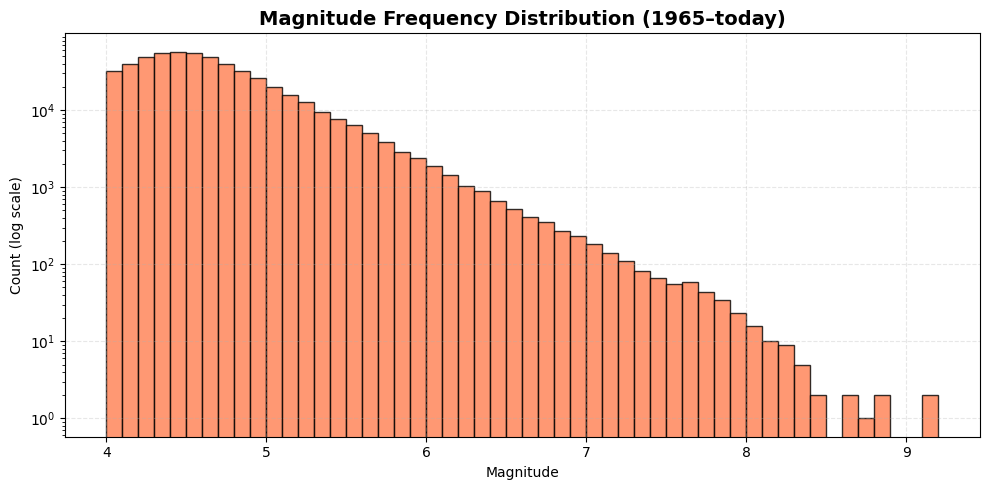

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(m4_era['mag'], bins=np.arange(4.0, m4_era['mag'].max() + 0.2, 0.1),
        color='coral', edgecolor='black', alpha=0.8)
ax.set_yscale('log')
ax.set_xlabel('Magnitude')
ax.set_ylabel('Count (log scale)')
ax.set_title(f'Magnitude Frequency Distribution ({M4_COMPLETE_FROM}–today)',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
save_fig(fig, '07_magnitude_distribution.png')
plt.show()

## Stats

In [9]:
complete_df = df[df['year'] < current_year]
partial_df = df[df['year'] == current_year]
m4_complete = complete_df[complete_df['year'] >= M4_COMPLETE_FROM]
n_m4_years = m4_complete['year'].nunique()
m7_complete = complete_df[complete_df['mag'] >= 7.0]
n_m7_years = m7_complete['year'].nunique()

print(f'Total events:             {len(df):,}  ({len(complete_df):,} complete + {len(partial_df):,} partial)')
print(f'M≥4 catalog range:        {m4_complete["time"].min():%Y-%m-%d}  →  '
      f'{m4_complete["time"].max():%Y-%m-%d}  ({n_m4_years} complete years)')
print(f'M≥7 catalog range:        {m7_complete["time"].min():%Y-%m-%d}  →  '
      f'{m7_complete["time"].max():%Y-%m-%d}  ({n_m7_years} complete years)')
print(f'Partial year:             {current_year}  ({year_fraction:.1%} elapsed, '
      f'{len(partial_df):,} events so far)')
print(f'Magnitude range:          {df["mag"].min():.1f}  →  {df["mag"].max():.1f}')
print()
print(f'Counts by magnitude band, M≥4 era ({M4_COMPLETE_FROM}–{current_year - 1}, complete years):')
for lo, hi, label in bands:
    n = ((m4_complete['mag'] >= lo) & (m4_complete['mag'] < hi)).sum()
    rate = n / n_m4_years
    print(f'  {label:5s}  {n:>9,}    ({rate:>7.1f}/yr)')
print()
print('Top 10 largest events:')
top = df.nlargest(10, 'mag')[['time', 'mag', 'place']]
for _, row in top.iterrows():
    print(f'  {row["time"]:%Y-%m-%d}  M{row["mag"]:.1f}  {row["place"]}')

Total events:             530,895  (525,572 complete + 5,323 partial)
M≥4 catalog range:        1965-01-01  →  2025-12-31  (61 complete years)
M≥7 catalog range:        1900-01-05  →  2025-12-08  (126 complete years)
Partial year:             2026  (36.4% elapsed, 5,323 events so far)
Magnitude range:          3.4  →  9.5

Counts by magnitude band, M≥4 era (1965–2025, complete years):
  M4       430,940    ( 7064.6/yr)
  M5        85,390    ( 1399.8/yr)
  M6         7,639    (  125.2/yr)
  M7           792    (   13.0/yr)
  M8+           49    (    0.8/yr)

Top 10 largest events:
  1960-05-22  M9.5  1960 Great Chilean Earthquake (Valdivia Earthquake)
  1964-03-28  M9.2  The 1964 Prince William Sound, Alaska Earthquake
  2004-12-26  M9.1  2004 Sumatra - Andaman Islands Earthquake
  2011-03-11  M9.1  2011 Great Tohoku Earthquake, Japan
  1952-11-04  M9.0  89 km ESE of Petropavlovsk-Kamchatsky, Russia
  1906-01-31  M8.8  1906 Ecuador-Colombia Earthquake
  2010-02-27  M8.8  2010 Maule, Chi